# 16 — Transient structural surrogate (temporal schemes and BPTT)

Notebook 10 learned a *static* deformation surrogate: one load in, one deformed
state out. Real crash and deformation problems are transient — the structure
oscillates, and a surrogate has to carry its own state forward. This notebook runs
the transient recipe end to end:

1. a **real implicit-dynamic Kratos solve** (StructuralMechanics, Bossak scheme) of a
   cantilever released under a sudden tip load, stepped through
   `RunTransientAnalysis` so every converged step is collected,
2. `temporal_training.CreateTrajectoryWindowDataset` windows the trajectory into
   single-step samples and `TrainModel` fits a small surrogate,
3. `TrainAutoregressive` continues training **through the rollout itself** (BPTT,
   with optional per-step gradient checkpointing) — the step that actually
   stabilizes long rollouts,
4. `EvaluateRollout` compares the error-growth curves, and the trained model is
   deployed unchanged through `TimeSeriesInferenceProcess`.

The window convention is shared by all of them — K states concatenated per node,
oldest first — which is exactly why the last step needs no adapter.


In [1]:
import sys
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
from KratosMultiphysics.PhysicsNeMoApplication import temporal_training
from KratosMultiphysics.PhysicsNeMoApplication import training_utils
from KratosMultiphysics.PhysicsNeMoApplication import rollout_utils
from KratosMultiphysics.PhysicsNeMoApplication import time_series_inference_process

# the in-memory transient cases live with the tests, found by walking up rather
# than by a path relative to the process' working directory: a notebook has no
# __file__, and cwd is only the notebook's own directory by Jupyter convention
def FindCases():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "tests" / "kratos_solver_cases"
        if candidate.is_dir():
            return candidate.resolve()
    raise FileNotFoundError(
        f"could not find tests/kratos_solver_cases above {Path.cwd()}")


CASES = FindCases()
sys.path.insert(0, str(CASES))
import structural_case
import transient_harness

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)
print("cases from:", CASES)


cases from: /home/vicente/src/Kratos/applications/PhysicsNeMoApplication/tests/kratos_solver_cases


## A real transient solve

`CreateTransientStructuralAnalysis` is the static cantilever of notebook 10 switched
to the implicit dynamic solver (`solver_type: "dynamic"`, `scheme_type: "bossak"`,
`damp_factor_m = -0.3`), with `DENSITY` on the properties for the mass matrix and
`VELOCITY`/`ACCELERATION` in the historical database. `RunTransientAnalysis` is
`AnalysisStage`'s own solution loop opened up so a state can be collected after each
converged step.


trajectory: (60, 49, 2) (steps, nodes, components)
peak tip deflection: -6.072 mm


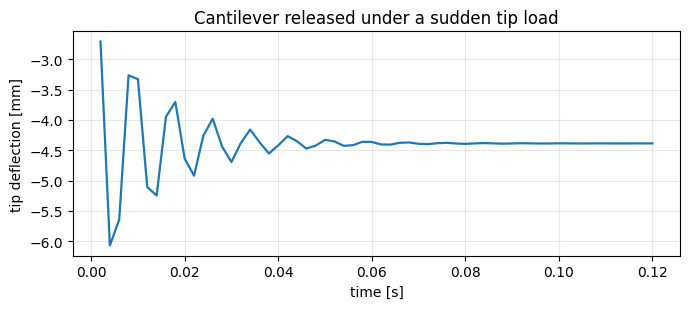

In [2]:
model = Kratos.Model()
analysis = structural_case.CreateTransientStructuralAnalysis(
    model, tip_load=1.0e6, divisions=6, time_step=0.002, end_time=0.12)

states = transient_harness.RunTransientAnalysis(
    analysis, collect=structural_case.CollectDisplacements)
model_part = model["StructuralModelPart"]
print("trajectory:", states.shape, "(steps, nodes, components)")

tip_row = max(range(states.shape[1]),
              key=lambda row: abs(states[:, row, 1]).max())
times = numpy.arange(1, states.shape[0] + 1) * 0.002

plt.figure(figsize=(7, 3.2))
plt.plot(times, states[:, tip_row, 1] * 1e3, lw=1.6)
plt.xlabel("time [s]"); plt.ylabel("tip deflection [mm]")
plt.title("Cantilever released under a sudden tip load")
plt.grid(alpha=0.3); plt.tight_layout()

print(f"peak tip deflection: {states[:, tip_row, 1].min() * 1e3:.3f} mm")


## Single-step training

`CreateTrajectoryWindowDataset` with `"scheme": "single_step"` turns the trajectory
into (window → next state) pairs: the window is the last K states concatenated per
node, oldest first. The samples are row-batched `(N, ...)` tensors, so
`training_utils.TrainModel` consumes them directly.

The raw displacements are ~1e-3 m, so we train on a normalized trajectory — the
usual conditioning step, not a detail of this bridge.


In [3]:
HISTORY = 2
scale = float(numpy.abs(states).max())
scaled = states / scale
width = states.shape[2]

dataset = temporal_training.CreateTrajectoryWindowDataset(scaled, Kratos.Parameters(
    '{"scheme": "single_step", "history_size": %d}' % HISTORY))
print(len(dataset), "single-step samples; window", tuple(dataset[0][0].shape))

def make_model(seed):
    torch.manual_seed(seed)
    return torch.nn.Sequential(
        torch.nn.Linear(HISTORY * width, 64), torch.nn.Tanh(),
        torch.nn.Linear(64, 64), torch.nn.Tanh(),
        torch.nn.Linear(64, width))

single_step_model = make_model(0)
history = training_utils.TrainModel(single_step_model, dataset, Kratos.Parameters("""{
    "epochs"        : 500,
    "batch_size"    : 8,
    "learning_rate" : 1.5e-3,
    "device"        : "auto",
    "echo_interval" : 100,
    "seed"          : 0
}"""))
print(f"single-step loss: {history[0]:.3e} -> {history[-1]:.3e}")


58 single-step samples; window (49, 4)
single-step loss: 3.804e-02 -> 8.226e-04


## Backpropagation through the rollout

A model with a tiny one-step error can still drift badly once it consumes its own
predictions. `TrainAutoregressive` seeds the model with K true states, rolls it
forward `rollout_steps` through its **own** outputs, and backpropagates through the
whole rollout. `"gradient_checkpointing": true` recomputes each step's activations
in backward — memory for compute on long rollouts, with gradients identical to the
plain path (pinned by test).

This needs its own loop: `TrainModel`'s epoch callbacks run under `eval()` +
`no_grad` and cannot train.


In [4]:
import copy

bptt_model = copy.deepcopy(single_step_model)
bptt_history = temporal_training.TrainAutoregressive(bptt_model, scaled, Kratos.Parameters("""{
    "epochs"                 : 120,
    "rollout_steps"          : 8,
    "history_size"           : 2,
    "learning_rate"          : 5e-4,
    "gradient_checkpointing" : true,
    "device"                 : "auto",
    "echo_interval"          : 40,
    "seed"                   : 0
}"""))
print(f"rollout loss: {bptt_history[0]:.3e} -> {bptt_history[-1]:.3e}")


rollout loss: 1.805e-03 -> 8.248e-04


## Error growth: one-step training vs BPTT

`EvaluateRollout` seeds the history with true states and then feeds the model its own
predictions for the rest of the trajectory — the deployment behaviour — returning the
per-step RMS error curve.


mean rollout error  untrained: 0.2520
                  single-step: 0.1734
                       + BPTT: 0.0647


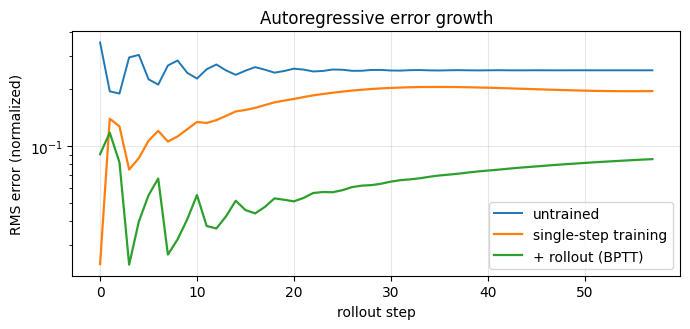

In [5]:
_, single_errors = rollout_utils.EvaluateRollout(
    single_step_model.cpu(), scaled, history_size=HISTORY)
_, bptt_errors = rollout_utils.EvaluateRollout(
    bptt_model.cpu(), scaled, history_size=HISTORY)
_, untrained_errors = rollout_utils.EvaluateRollout(
    make_model(7), scaled, history_size=HISTORY)

plt.figure(figsize=(7, 3.4))
plt.semilogy(untrained_errors, label="untrained", lw=1.4)
plt.semilogy(single_errors, label="single-step training", lw=1.6)
plt.semilogy(bptt_errors, label="+ rollout (BPTT)", lw=1.6)
plt.xlabel("rollout step"); plt.ylabel("RMS error (normalized)")
plt.title("Autoregressive error growth"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()

print(f"mean rollout error  untrained: {untrained_errors.mean():.4f}")
print(f"                  single-step: {single_errors.mean():.4f}")
print(f"                       + BPTT: {bptt_errors.mean():.4f}")


## Deployment

Because the window convention is shared, the trained model drops into
`TimeSeriesInferenceProcess` with no adapter: the process keeps its own K-state deque
of gathered inputs, concatenates them oldest-first, and writes the prediction back
into Kratos variables. Here it predicts the next `DISPLACEMENT` from the last two
states of the solved trajectory.


In [6]:
# the process works on 3-component DISPLACEMENT; wrap the planar model
class PlanarToThreeComponent(torch.nn.Module):
    """Drops the unused Z column, applies the training normalization, and
    pads the planar prediction back to 3 components (TorchScript-friendly:
    the history size and scale are attributes, not captured globals)."""

    def __init__(self, inner, history_size: int, scale: float):
        super().__init__()
        self.inner = inner
        self.history_size = history_size
        self.scale = scale

    def forward(self, window):
        rows = window.shape[0]
        planar = window.reshape(rows, self.history_size, 3)[:, :, :2].reshape(rows, -1)
        prediction = self.inner(planar / self.scale) * self.scale
        return torch.cat([prediction, torch.zeros_like(prediction[:, :1])], dim=1)

deployable = PlanarToThreeComponent(bptt_model, HISTORY, scale)
training_utils.SaveTrainedModel(deployable, OUTPUT / "transient_surrogate.pt", card={
    "input_fields":  [{"variable_name": "DISPLACEMENT", "data_location": "node_historical"}],
    "output_fields": [{"variable_name": "DISPLACEMENT", "data_location": "node_non_historical"}],
})

process = time_series_inference_process.Factory(Kratos.Parameters("""{
    "Parameters": {
        "model_part_name" : "StructuralModelPart",
        "model_settings"  : {
            "checkpoint_file" : "output/transient_surrogate.pt",
            "checkpoint_type" : "torchscript"
        },
        "input_fields"    : [ { "variable_name" : "DISPLACEMENT", "data_location" : "node_historical" } ],
        "output_fields"   : [ { "variable_name" : "DISPLACEMENT", "data_location" : "node_non_historical" } ],
        "history_size"    : 2
    }
}"""), model)

# replay the last two solved states through the process
for step, state in enumerate(states[-3:-1], start=1):
    for node, row in zip(model_part.Nodes, state):
        node.SetSolutionStepValue(Kratos.DISPLACEMENT, [row[0], row[1], 0.0])
    model_part.ProcessInfo[Kratos.STEP] = step
    process.ExecuteFinalizeSolutionStep()

predicted = numpy.array([node.GetValue(Kratos.DISPLACEMENT)[1] for node in model_part.Nodes])
truth = states[-1][:, 1]
error = numpy.sqrt(numpy.mean((predicted - truth) ** 2)) / numpy.abs(truth).max()
print(f"in-loop next-step prediction, relative RMS error: {error:.4%}")


in-loop next-step prediction, relative RMS error: 0.8085%


## Variations

- **Other schemes**: `"one_shot"` (initial window → final state) is the crash-outcome
  framing; `"time_conditional"` adds a normalized-time channel and predicts any step
  directly, avoiding error accumulation but learning no dynamics.
- **Richer architectures**: the window contract is just `(N, K·W) → (N, W)`, so
  MeshGraphNet, Transolver or FIGConvUNet slot in wherever the per-node MLP sits here
  (a GNN additionally sees the mesh graph from `graph_bridge`).
- **Exact transient physics**: `differentiable_residual` now covers transients too —
  build the assembler with `scheme=Kratos.ResidualBasedBossakDisplacementScheme(-0.3)`
  and call `InitializeSolutionStep()` per step to add the exact dynamic residual as a
  training loss.
